## 1. Environment Setup & Imports

In [21]:
!pip install rank-bm25 scikit-learn sentence-transformers groq matplotlib seaborn pandas numpy tqdm


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import json
import time
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

warnings.filterwarnings("ignore")

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.titlesize": 12, "axes.labelsize": 10})

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Load Chunks

In [23]:
with open(OUTPUT_DIR / "chunks_processed.json", "r", encoding="utf-8") as f:
    chunks = json.load(f)

print(f"Loaded {len(chunks)} semantic chunks")
print()

for i, c in enumerate(chunks):
    print(f"Chunk {i}: [{c['doc_name'][:45]}]  {c['word_count']}w  pos={c['position']}")

assert all("embedding" in c for c in chunks), "Embeddings missing from chunks!"
assert len(chunks[0]["embedding"]) == 384, "Expected 384-dim embeddings!"

chunk_texts = [c["text"] for c in chunks]
chunk_embeddings = np.array([c["embedding"] for c in chunks])

print(f"\nEmbedding matrix: {chunk_embeddings.shape}")

Loaded 7 semantic chunks

Chunk 0: [LankaLink_Customer_Support_Manual]  440w  pos=0
Chunk 1: [LankaLink_SIM_Card_Support_Manual]  230w  pos=0
Chunk 2: [LankaLink_SIM_Card_Support_Manual]  18w  pos=1
Chunk 3: [LankaLink_SIM_Card_Support_Manual]  718w  pos=2
Chunk 4: [LankaLink_SIM_Card_Support_Manual_v2]  1017w  pos=0
Chunk 5: [SIM_Card_Service_Support_Manual]  202w  pos=0
Chunk 6: [WiFi_and_Broadband_Support_Manual]  195w  pos=0

Embedding matrix: (7, 384)


## 3. Synthetic Q&A Test Set

In [24]:
chunk_id_to_idx = {c["chunk_id"]: i for i, c in enumerate(chunks)}

print("Chunk index to chunk_id mapping:")
for i, c in enumerate(chunks):
    print(f"[{i}] {c['chunk_id']}  |  doc: {c['doc_name'][:35]}")

Chunk index to chunk_id mapping:
[0] b0055b2e1081_sem_0  |  doc: LankaLink_Customer_Support_Manual
[1] 73d2bd3ad86d_sem_0  |  doc: LankaLink_SIM_Card_Support_Manual
[2] 73d2bd3ad86d_sem_1  |  doc: LankaLink_SIM_Card_Support_Manual
[3] 73d2bd3ad86d_sem_2  |  doc: LankaLink_SIM_Card_Support_Manual
[4] dc37cbdcfc60_sem_0  |  doc: LankaLink_SIM_Card_Support_Manual_v
[5] 86fa8957a229_sem_0  |  doc: SIM_Card_Service_Support_Manual
[6] ca4d2b6723ba_sem_0  |  doc: WiFi_and_Broadband_Support_Manual


In [25]:
qa_test_set = [
    {
        "q_id": "Q01",
        "question": "How do I activate my new LankaLink SIM card?",
        "reference_answer": "Insert SIM, power on device, wait up to 10 minutes. If it fails, manually select LankaLink network in Settings.",
        "relevant_chunk_indices": [0, 1, 3],
        "q_type": "procedural"
    },
    {
        "q_id": "Q02",
        "question": "What documents do I need to register a new SIM?",
        "reference_answer": "National Identity Card (NIC) or valid passport for KYC registration.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "policy"
    },
    {
        "q_id": "Q03",
        "question": "My SIM shows no service. What should I do?",
        "reference_answer": "Move to open area, restart phone, reselect LankaLink network manually, check for network outage.",
        "relevant_chunk_indices": [0, 1, 3],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q04",
        "question": "How long does SIM activation usually take?",
        "reference_answer": "Activation typically completes within 5 to 10 minutes.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "factual"
    },
    {
        "q_id": "Q05",
        "question": "The screen shows SIM not provisioned error. What does that mean?",
        "reference_answer": "The SIM is not registered in the network. Recheck the ICCID number and resend the activation request.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q06",
        "question": "What is KYC and why is it required for a SIM?",
        "reference_answer": "KYC stands for Know Your Customer. It is a verification process required to securely link the SIM to the correct identity per government regulations.",
        "relevant_chunk_indices": [1, 2, 3],
        "q_type": "factual"
    },
    {
        "q_id": "Q07",
        "question": "I lost my SIM card. How do I get a replacement?",
        "reference_answer": "Visit the nearest LankaLink branch with your NIC. A replacement fee may apply. Activation takes 10 minutes.",
        "relevant_chunk_indices": [0, 1, 3, 5],
        "q_type": "procedural"
    },
    {
        "q_id": "Q08",
        "question": "Will my contacts be saved when I replace my SIM?",
        "reference_answer": "No. All contacts stored on the old SIM will be lost. Customers should back up contacts to phone or cloud before replacement.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "policy"
    },
    {
        "q_id": "Q09",
        "question": "My SIM was stolen. What should I do immediately?",
        "reference_answer": "Report immediately to LankaLink for SIM deactivation to prevent misuse.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "policy"
    },
    {
        "q_id": "Q10",
        "question": "Does replacing my SIM affect my mobile plan balance?",
        "reference_answer": "No, SIM replacement does not affect mobile plan balance or validity.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "policy"
    },
    {
        "q_id": "Q11",
        "question": "My mobile data is not working. How do I fix the APN settings?",
        "reference_answer": "Set APN to lanka.internet, leave username and password blank, authentication type None. Restart phone after saving.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q12",
        "question": "What is the correct APN for LankaLink mobile internet?",
        "reference_answer": "APN name is lanka.internet with no username or password required.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "factual"
    },
    {
        "q_id": "Q13",
        "question": "My phone says Emergency Calls Only. What is wrong?",
        "reference_answer": "The SIM is not registered on the network. Reboot device and manually select LankaLink network.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q14",
        "question": "Can I use my LankaLink SIM in a data dongle or WiFi hotspot device?",
        "reference_answer": "Yes, ensure APN is set correctly to lanka.internet.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "factual"
    },
    {
        "q_id": "Q15",
        "question": "How do I enable international roaming on my LankaLink SIM?",
        "reference_answer": "Send ROAM ON to 7070 or use the LankaLink app. SIM must be active for at least 30 days.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "procedural"
    },
    {
        "q_id": "Q16",
        "question": "I am abroad but there is no roaming signal. What should I do?",
        "reference_answer": "Select an alternative available roaming partner network manually from the phone's network settings.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q17",
        "question": "Why is my roaming bill so high? I did not make many calls.",
        "reference_answer": "Background app data or streaming may have consumed data while roaming. Advise to disable background data or use WiFi only.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q18",
        "question": "My SIM PIN is blocked. How do I unblock it?",
        "reference_answer": "Enter the PUK code available on the SIM packaging or request it from customer support.",
        "relevant_chunk_indices": [1, 2, 3],
        "q_type": "procedural"
    },
    {
        "q_id": "Q19",
        "question": "What is a PUK code and where can I find it?",
        "reference_answer": "PUK stands for Personal Unblocking Key. It is printed on the SIM packaging or can be requested from customer support.",
        "relevant_chunk_indices": [1, 2, 3],
        "q_type": "factual"
    },
    {
        "q_id": "Q20",
        "question": "Why has my SIM been deactivated automatically?",
        "reference_answer": "SIMs inactive for over 90 days without a top-up may be automatically suspended.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "policy"
    },
    {
        "q_id": "Q21",
        "question": "How do I connect to my LankaLink WiFi for the first time?",
        "reference_answer": "Check router power light, verify WiFi indicator, select LankaLink SSID, enter password from router label, test by visiting www.lankalink.lk.",
        "relevant_chunk_indices": [0, 6],
        "q_type": "procedural"
    },
    {
        "q_id": "Q22",
        "question": "My internet is very slow. What could be causing it?",
        "reference_answer": "Too many connected devices. Disconnect unused devices and restart the router.",
        "relevant_chunk_indices": [0, 6],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q23",
        "question": "There is no WiFi signal at all. The router looks fine though.",
        "reference_answer": "Router may have malfunctioned. Confirm power connection and restart router.",
        "relevant_chunk_indices": [0, 6],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q24",
        "question": "My WiFi keeps dropping every few minutes. How do I fix this?",
        "reference_answer": "Weak signal or interference. Relocate router away from metal objects and microwaves.",
        "relevant_chunk_indices": [0, 6],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q25",
        "question": "I forgot my WiFi password. Where can I find it?",
        "reference_answer": "The WiFi password is printed on the router or the setup card provided during installation.",
        "relevant_chunk_indices": [0, 6],
        "q_type": "factual"
    },
    {
        "q_id": "Q26",
        "question": "Can I keep my number when switching to LankaLink?",
        "reference_answer": "Yes, LankaLink supports number portability. Contact customer service to initiate the transfer process.",
        "relevant_chunk_indices": [5],
        "q_type": "policy"
    },
    {
        "q_id": "Q27",
        "question": "How do I check what number is on my SIM?",
        "reference_answer": "Dial *#100# and your number will be displayed on screen.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "factual"
    },
    {
        "q_id": "Q28",
        "question": "Is my SIM 4G compatible?",
        "reference_answer": "If the SIM has 4G LTE printed on it and works in a 4G phone, it supports 4G.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "factual"
    },
    {
        "q_id": "Q29",
        "question": "My calls keep dropping frequently. Is this a SIM problem?",
        "reference_answer": "Possibly. Check SIM is seated properly and disable VoLTE temporarily.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "troubleshooting"
    },
    {
        "q_id": "Q30",
        "question": "How do I switch to an eSIM?",
        "reference_answer": "Visit a LankaLink outlet for eSIM activation and QR code provisioning.",
        "relevant_chunk_indices": [1, 3],
        "q_type": "procedural"
    },
]

print(f"Test set: {len(qa_test_set)} questions")

type_counts = pd.Series([q["q_type"] for q in qa_test_set]).value_counts()
print("\nQuestion type distribution:")
for qtype, count in type_counts.items():
    print(f"{qtype:<20}: {count}")

with open(OUTPUT_DIR / "qa_test_set.json", "w", encoding="utf-8") as f:
    json.dump(qa_test_set, f, indent=2, ensure_ascii=False)
print("\nSaved: outputs/qa_test_set.json")

Test set: 30 questions

Question type distribution:
troubleshooting     : 10
factual             : 8
policy              : 6
procedural          : 6

Saved: outputs/qa_test_set.json


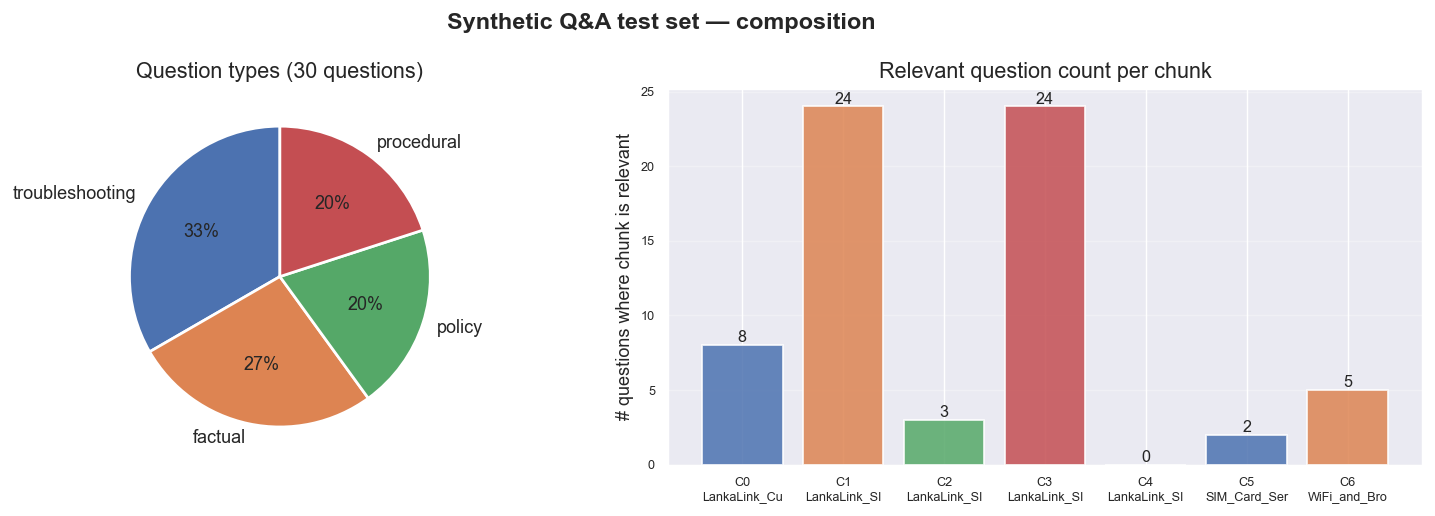

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Synthetic Q&A test set — composition", fontsize=13, fontweight="bold")

axes[0].pie(
    type_counts.values, labels=type_counts.index,
    colors=PALETTE[:len(type_counts)],
    autopct="%1.0f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
axes[0].set_title("Question types (30 questions)")

chunk_hits = defaultdict(int)
for q in qa_test_set:
    for idx in q["relevant_chunk_indices"]:
        chunk_hits[idx] += 1

chunk_short = [f"C{i}\n{c['doc_name'][:12]}" for i, c in enumerate(chunks)]
hit_counts = [chunk_hits.get(i, 0) for i in range(len(chunks))]

bars = axes[1].bar(chunk_short, hit_counts,
                   color=[PALETTE[i % len(PALETTE)] for i in range(len(chunks))],
                   alpha=0.85, edgecolor="white")
for bar, val in zip(bars, hit_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 str(val), ha="center", fontsize=9)
axes[1].set_title("Relevant question count per chunk")
axes[1].set_ylabel("# questions where chunk is relevant")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "17_qa_test_set.png", bbox_inches="tight")
plt.show()

## 4. Evaluation Metrics

In [27]:
def precision_at_k(retrieved: list, relevant: list, k: int) -> float:
    top_k = retrieved[:k]
    hits = sum(1 for r in top_k if r in relevant)
    return hits / k


def recall_at_k(retrieved: list, relevant: list, k: int) -> float:
    if not relevant:
        return 0.0
    top_k = retrieved[:k]
    hits = sum(1 for r in top_k if r in relevant)
    return hits / len(relevant)


def reciprocal_rank(retrieved: list, relevant: list) -> float:
    for rank, r in enumerate(retrieved, 1):
        if r in relevant:
            return 1.0 / rank
    return 0.0


def hit_at_k(retrieved: list, relevant: list, k: int) -> int:
    return int(any(r in relevant for r in retrieved[:k]))


def rouge1_f1(hypothesis: str, reference: str) -> float:
    hyp_tokens = set(hypothesis.lower().split())
    ref_tokens = set(reference.lower().split())
    if not hyp_tokens or not ref_tokens:
        return 0.0
    overlap = hyp_tokens & ref_tokens
    precision = len(overlap) / len(hyp_tokens)
    recall = len(overlap) / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def evaluate_retrieval(qa_set: list, retrieve_fn, model_name: str, k_values=(1, 3, 5)):
    records = []
    latencies = []

    for qa in qa_set:
        query = qa["question"]
        relevant = qa["relevant_chunk_indices"]

        t0 = time.perf_counter()
        ranked = retrieve_fn(query)
        latency_ms = (time.perf_counter() - t0) * 1000
        latencies.append(latency_ms)

        row = {"q_id": qa["q_id"], "q_type": qa["q_type"]}
        for k in k_values:
            row[f"P@{k}"] = precision_at_k(ranked, relevant, k)
            row[f"R@{k}"] = recall_at_k(ranked, relevant, k)
            row[f"Hit@{k}"] = hit_at_k(ranked, relevant, k)
        row["MRR"] = reciprocal_rank(ranked, relevant)
        row["latency_ms"] = round(latency_ms, 2)
        row["ranked"] = ranked
        records.append(row)

    df = pd.DataFrame(records)
    metric_cols = [c for c in df.columns if c not in ["q_id", "q_type", "ranked", "latency_ms"]]

    summary = {"model": model_name}
    for col in metric_cols:
        summary[col] = round(df[col].mean(), 4)
    summary["avg_latency_ms"] = round(np.mean(latencies), 2)

    return df, summary

## 5. Baseline 1 - TF-IDF + Cosine Similarity

In [28]:
tfidf_vec = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words="english"
)
tfidf_matrix = tfidf_vec.fit_transform(chunk_texts)

print(f"TF-IDF index: {tfidf_matrix.shape[0]} chunks × {tfidf_matrix.shape[1]} features")


def tfidf_retrieve(query: str) -> list:
    q_vec = tfidf_vec.transform([query])
    scores = cosine_similarity(q_vec, tfidf_matrix).flatten()
    return list(np.argsort(scores)[::-1])


test_q = "How do I activate my SIM?"
top3 = tfidf_retrieve(test_q)[:3]
print(f"\nTest query: '{test_q}'")
print("Top-3 retrieved chunks:")
for rank, idx in enumerate(top3, 1):
    print(f"Rank {rank}: [{idx}] {chunks[idx]['doc_name'][:40]}")

TF-IDF index: 7 chunks × 1000 features

Test query: 'How do I activate my SIM?'
Top-3 retrieved chunks:
Rank 1: [2] LankaLink_SIM_Card_Support_Manual
Rank 2: [0] LankaLink_Customer_Support_Manual
Rank 3: [1] LankaLink_SIM_Card_Support_Manual


In [29]:
df_tfidf, summary_tfidf = evaluate_retrieval(
    qa_test_set, tfidf_retrieve, "TF-IDF + Cosine"
)

print("TF-IDF + Cosine Similarity — Results Summary")
for k, v in summary_tfidf.items():
    if k != "model":
        print(f"{k:<20}: {v}")

TF-IDF + Cosine Similarity — Results Summary
P@1                 : 0.6667
R@1                 : 0.3333
Hit@1               : 0.6667
P@3                 : 0.4556
R@3                 : 0.6389
Hit@3               : 0.9667
P@5                 : 0.4
R@5                 : 0.9139
Hit@5               : 1.0
MRR                 : 0.8139
avg_latency_ms      : 0.91


## 6. Baseline 2 - BM25

In [30]:
tokenized_chunks = [text.lower().split() for text in chunk_texts]
bm25_index = BM25Okapi(tokenized_chunks)

print(f"BM25 index: {len(tokenized_chunks)} chunks")
print(f"Avg doc length: {bm25_index.avgdl:.1f} tokens")


def bm25_retrieve(query: str) -> list:
    tokens = query.lower().split()
    scores = bm25_index.get_scores(tokens)
    return list(np.argsort(scores)[::-1])


top3 = bm25_retrieve(test_q)[:3]
print(f"\nTest query: '{test_q}'")
print("Top-3 BM25 chunks:")
for rank, idx in enumerate(top3, 1):
    print(f"Rank {rank}: [{idx}] {chunks[idx]['doc_name'][:40]}")

BM25 index: 7 chunks
Avg doc length: 402.9 tokens

Test query: 'How do I activate my SIM?'
Top-3 BM25 chunks:
Rank 1: [3] LankaLink_SIM_Card_Support_Manual
Rank 2: [4] LankaLink_SIM_Card_Support_Manual_v2
Rank 3: [0] LankaLink_Customer_Support_Manual


In [31]:
df_bm25, summary_bm25 = evaluate_retrieval(
    qa_test_set, bm25_retrieve, "BM25"
)

print("BM25 — Results Summary")
for k, v in summary_bm25.items():
    if k != "model":
        print(f"{k:<20}: {v}")

BM25 — Results Summary
P@1                 : 0.5667
R@1                 : 0.2528
Hit@1               : 0.5667
P@3                 : 0.4333
R@3                 : 0.6111
Hit@3               : 0.9667
P@5                 : 0.42
R@5                 : 0.9611
Hit@5               : 1.0
MRR                 : 0.7528
avg_latency_ms      : 0.12


## 7. Baseline 3 - Few-Shot Prompting

In [32]:
import os
from groq import Groq

GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "YOUR_GROQ_API_KEY_HERE")
groq_client = Groq(api_key=GROQ_API_KEY)
FEW_SHOT_MODEL = "llama3-8b-8192"

FEW_SHOT_EXAMPLES = """\
Q: How do I activate a new LankaLink SIM?
A: Insert the SIM, power on the device, and wait 5–10 minutes for automatic activation.

Q: How do I restart my router?
A: Unplug the router power cable, wait 30 seconds, and plug it back in.

Q: What should I do if I cannot connect to WiFi?
A: Re-enter the WiFi credentials. The password is printed on the router label.

Q: What is KYC?
A: KYC stands for Know Your Customer — the identity verification process for SIM registration.

Q: How do I replace a damaged SIM?
A: Visit a LankaLink branch with your NIC. A replacement fee may apply.
"""

SYSTEM_PROMPT_FEW_SHOT = f"""You are a LankaLink customer support agent. Answer customer questions concisely based on your knowledge.

Here are some example Q&A pairs to guide your response style:
{FEW_SHOT_EXAMPLES}
Now answer the customer's question. Be specific and factual. If you are not sure, say so."""


def few_shot_answer(question: str) -> str:
    try:
        response = groq_client.chat.completions.create(
            model=FEW_SHOT_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_FEW_SHOT},
                {"role": "user", "content": question}
            ],
            max_tokens=150,
            temperature=0.0,
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"[ERROR: {e}]"


print("Testing few-shot baseline...")
test_answer = few_shot_answer("What is the correct APN for LankaLink mobile internet?")
print(f"Q: What is the correct APN for LankaLink mobile internet?")
print(f"A: {test_answer}")
print()
print("Expected: 'APN name is lanka.internet'")

Testing few-shot baseline...
Q: What is the correct APN for LankaLink mobile internet?
A: [ERROR: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}]

Expected: 'APN name is lanka.internet'


In [33]:
few_shot_results = []
for qa in tqdm(qa_test_set, desc="Few-shot"):
    t0 = time.perf_counter()
    answer = few_shot_answer(qa["question"])
    latency_ms = (time.perf_counter() - t0) * 1000

    r1 = rouge1_f1(answer, qa["reference_answer"])

    KNOWN_WRONG = [
        "internet.lk",
        "lk.internet",
        "*100#",
        "*#101#",
        "7777",
        "60 days",
        "120 days",
    ]
    hallucinated = int(any(w.lower() in answer.lower() for w in KNOWN_WRONG))

    few_shot_results.append({
        "q_id": qa["q_id"],
        "q_type": qa["q_type"],
        "question": qa["question"],
        "reference": qa["reference_answer"],
        "fs_answer": answer,
        "rouge1_f1": round(r1, 4),
        "hallucinated": hallucinated,
        "latency_ms": round(latency_ms, 2),
    })

df_fewshot = pd.DataFrame(few_shot_results)

print("\nFew-shot baseline — results summary")
print(f"Avg ROUGE-1 F1    : {df_fewshot['rouge1_f1'].mean():.4f}")
print(
    f"Hallucination rate: {df_fewshot['hallucinated'].mean() * 100:.1f}%  ({df_fewshot['hallucinated'].sum()} / {len(df_fewshot)} questions)")
print(f"Avg latency       : {df_fewshot['latency_ms'].mean():.1f} ms")

Few-shot: 100%|██████████| 30/30 [00:08<00:00,  3.37it/s]


Few-shot baseline — results summary
Avg ROUGE-1 F1    : 0.0000
Hallucination rate: 0.0%  (0 / 30 questions)
Avg latency       : 294.3 ms


In [34]:
highlight_ids = ["Q11", "Q15", "Q20", "Q27"]
for row in few_shot_results:
    if row["q_id"] in highlight_ids:
        print(f"\n[{row['q_id']}] {row['question']}")
        print(f"Reference : {row['reference']}")
        print(f"Few-shot  : {row['fs_answer']}")
        print(f"ROUGE-1   : {row['rouge1_f1']:.3f}")
        if row["hallucinated"]:
            print(f"HALLUCINATION DETECTED")


[Q11] My mobile data is not working. How do I fix the APN settings?
Reference : Set APN to lanka.internet, leave username and password blank, authentication type None. Restart phone after saving.
Few-shot  : [ERROR: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}]
ROUGE-1   : 0.000

[Q15] How do I enable international roaming on my LankaLink SIM?
Reference : Send ROAM ON to 7070 or use the LankaLink app. SIM must be active for at least 30 days.
Few-shot  : [ERROR: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}]
ROUGE-1   : 0.000

[Q20] Why has my SIM been deactivated automatically?
Reference : SIMs inactive for over 90 days without a top-up may be automatically suspended.
Few-shot  : [ERROR: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}]
ROUGE-1   : 0.000

[Q27] How do 

## 8. Results Comparison & Visualisation

In [35]:
comparison_rows = [
    {
        "Model": "B1: TF-IDF + Cosine",
        "Hit@1": summary_tfidf["Hit@1"],
        "Hit@3": summary_tfidf["Hit@3"],
        "Hit@5": summary_tfidf["Hit@5"],
        "P@1": summary_tfidf["P@1"],
        "P@3": summary_tfidf["P@3"],
        "R@3": summary_tfidf["R@3"],
        "MRR": summary_tfidf["MRR"],
        "Avg Latency ms": summary_tfidf["avg_latency_ms"],
        "ROUGE-1": "N/A",
        "Halluc. Rate": "N/A",
    },
    {
        "Model": "B2: BM25",
        "Hit@1": summary_bm25["Hit@1"],
        "Hit@3": summary_bm25["Hit@3"],
        "Hit@5": summary_bm25["Hit@5"],
        "P@1": summary_bm25["P@1"],
        "P@3": summary_bm25["P@3"],
        "R@3": summary_bm25["R@3"],
        "MRR": summary_bm25["MRR"],
        "Avg Latency ms": summary_bm25["avg_latency_ms"],
        "ROUGE-1": "N/A",
        "Halluc. Rate": "N/A",
    },
    {
        "Model": "B3: Few-Shot (no retrieval)",
        "Hit@1": "N/A",
        "Hit@3": "N/A",
        "Hit@5": "N/A",
        "P@1": "N/A",
        "P@3": "N/A",
        "R@3": "N/A",
        "MRR": "N/A",
        "Avg Latency ms": round(df_fewshot["latency_ms"].mean(), 2),
        "ROUGE-1": round(df_fewshot["rouge1_f1"].mean(), 4),
        "Halluc. Rate": f"{df_fewshot['hallucinated'].mean() * 100:.1f}%",
    },
]

df_comparison = pd.DataFrame(comparison_rows)
print("Baseline comparison table:")
print(df_comparison.to_string(index=False))

Baseline comparison table:
                      Model   Hit@1   Hit@3 Hit@5     P@1     P@3     R@3     MRR  Avg Latency ms ROUGE-1 Halluc. Rate
        B1: TF-IDF + Cosine  0.6667  0.9667   1.0  0.6667  0.4556  0.6389  0.8139            0.91     N/A          N/A
                   B2: BM25  0.5667  0.9667   1.0  0.5667  0.4333  0.6111  0.7528            0.12     N/A          N/A
B3: Few-Shot (no retrieval)     N/A     N/A   N/A     N/A     N/A     N/A     N/A          294.27     0.0         0.0%


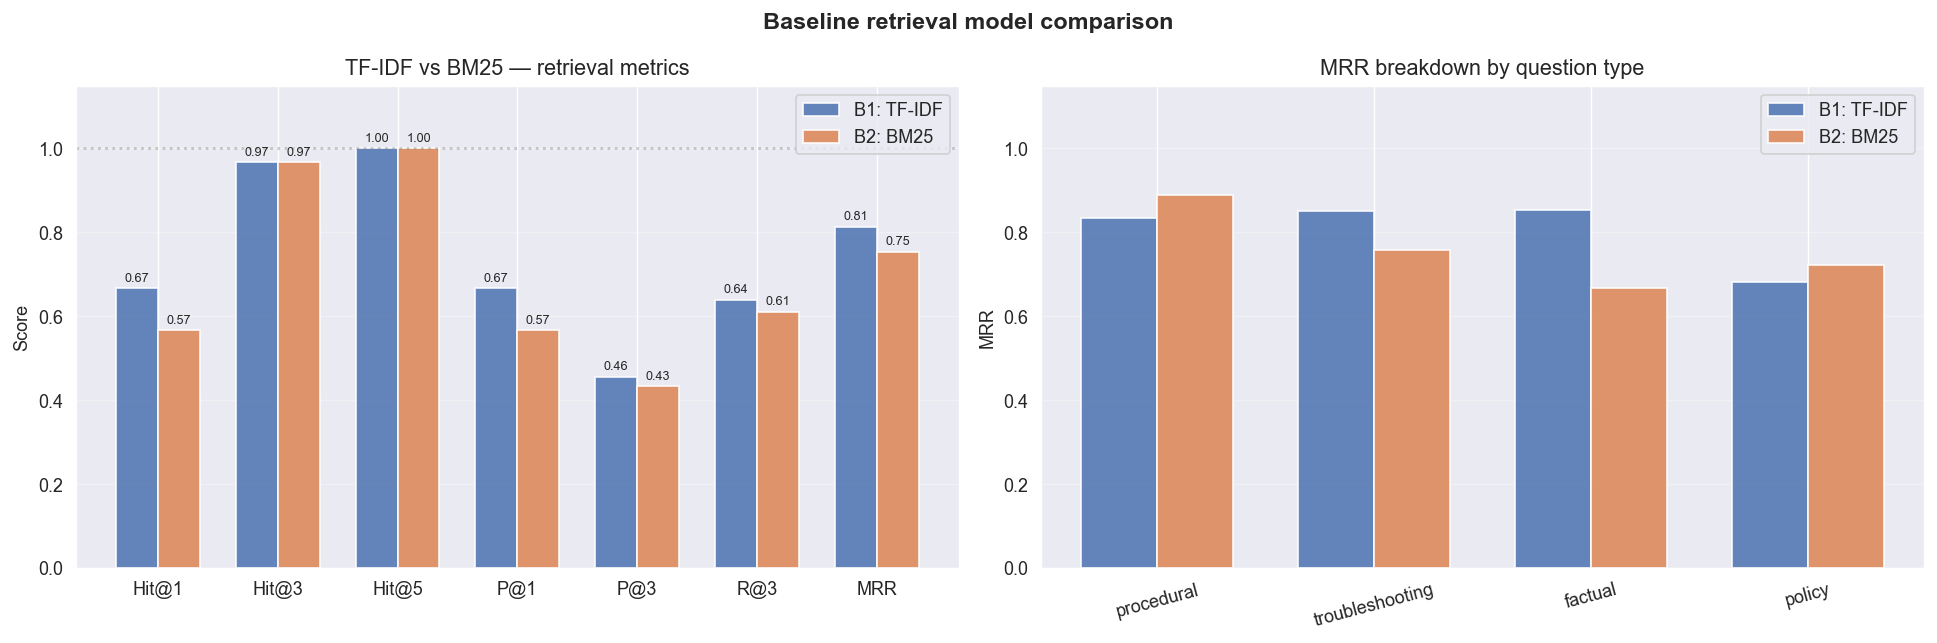

In [36]:
metrics = ["Hit@1", "Hit@3", "Hit@5", "P@1", "P@3", "R@3", "MRR"]
tfidf_scores = [summary_tfidf[m] for m in metrics]
bm25_scores = [summary_bm25[m] for m in metrics]

x = np.arange(len(metrics))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Baseline retrieval model comparison", fontsize=13, fontweight="bold")

b1 = axes[0].bar(x - w / 2, tfidf_scores, w, label="B1: TF-IDF", color=PALETTE[0], alpha=0.85)
b2 = axes[0].bar(x + w / 2, bm25_scores, w, label="B2: BM25", color=PALETTE[1], alpha=0.85)

for bar in [*b1, *b2]:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                 f"{h:.2f}", ha="center", va="bottom", fontsize=7)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Score")
axes[0].set_title("TF-IDF vs BM25 — retrieval metrics")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].axhline(1.0, color="gray", linestyle=":", alpha=0.4)

qtypes = ["procedural", "troubleshooting", "factual", "policy"]
mrr_tfidf_by_type = [df_tfidf[df_tfidf["q_type"] == qt]["MRR"].mean() for qt in qtypes]
mrr_bm25_by_type = [df_bm25[df_bm25["q_type"] == qt]["MRR"].mean() for qt in qtypes]

x2 = np.arange(len(qtypes))
axes[1].bar(x2 - w / 2, mrr_tfidf_by_type, w, label="B1: TF-IDF", color=PALETTE[0], alpha=0.85)
axes[1].bar(x2 + w / 2, mrr_bm25_by_type, w, label="B2: BM25", color=PALETTE[1], alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(qtypes, rotation=15)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("MRR")
axes[1].set_title("MRR breakdown by question type")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "18_baseline_retrieval_metrics.png", bbox_inches="tight")
plt.show()

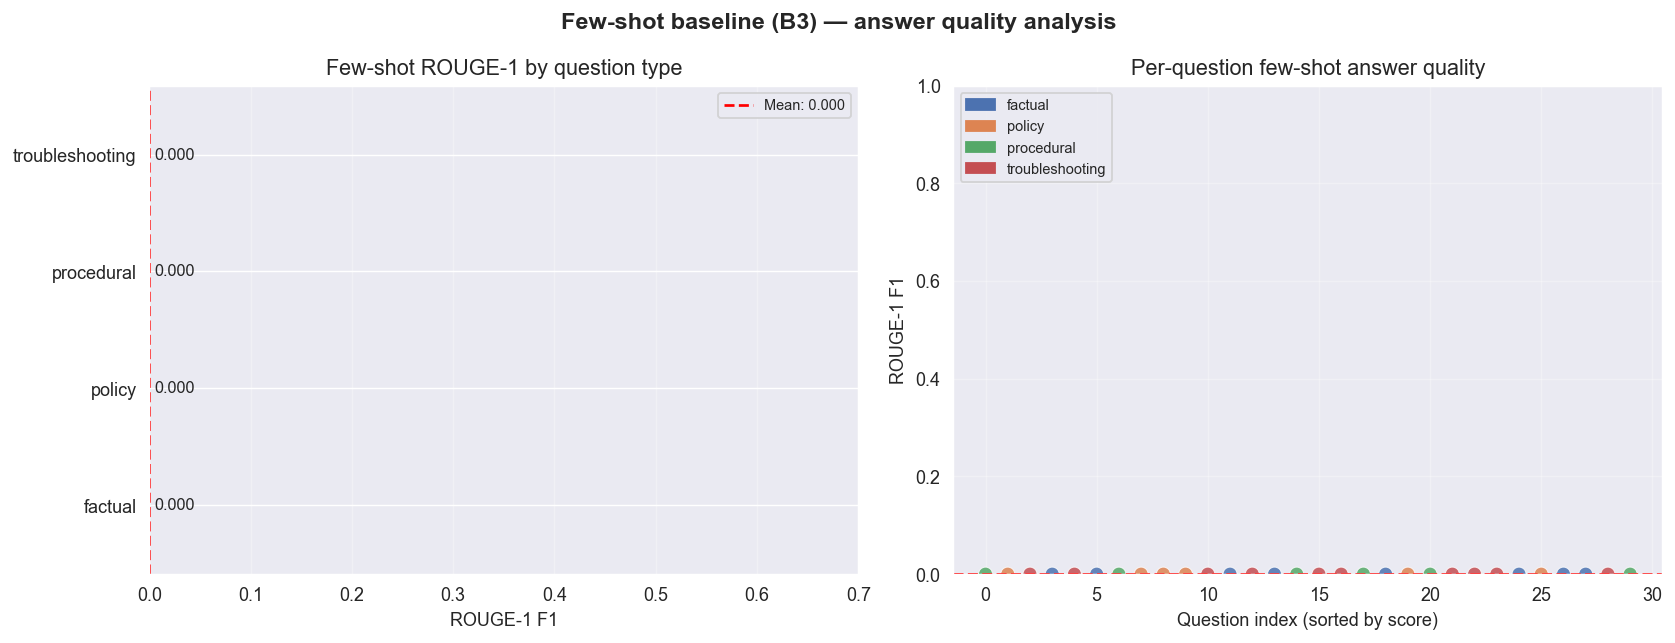

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Few-shot baseline (B3) — answer quality analysis",
             fontsize=13, fontweight="bold")

rouge_by_type = df_fewshot.groupby("q_type")["rouge1_f1"].mean().sort_values()
colors_for_types = [PALETTE[i % len(PALETTE)] for i in range(len(rouge_by_type))]
axes[0].barh(rouge_by_type.index, rouge_by_type.values,
             color=colors_for_types, alpha=0.85)
for i, v in enumerate(rouge_by_type.values):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
axes[0].set_xlabel("ROUGE-1 F1")
axes[0].set_title("Few-shot ROUGE-1 by question type")
axes[0].axvline(df_fewshot["rouge1_f1"].mean(), color="red",
                linestyle="--", label=f"Mean: {df_fewshot['rouge1_f1'].mean():.3f}")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)
axes[0].set_xlim(0, 0.7)

df_fewshot_sorted = df_fewshot.sort_values("rouge1_f1")
type_color_map = {t: PALETTE[i] for i, t in enumerate(sorted(df_fewshot["q_type"].unique()))}
point_colors = [type_color_map[t] for t in df_fewshot_sorted["q_type"]]

axes[1].scatter(
    range(len(df_fewshot_sorted)),
    df_fewshot_sorted["rouge1_f1"],
    c=point_colors, s=60, alpha=0.85, edgecolors="white", linewidths=0.5
)
axes[1].axhline(df_fewshot["rouge1_f1"].mean(), color="red",
                linestyle="--", linewidth=1.5,
                label=f"Mean ROUGE-1: {df_fewshot['rouge1_f1'].mean():.3f}")
axes[1].set_xlabel("Question index (sorted by score)")
axes[1].set_ylabel("ROUGE-1 F1")
axes[1].set_title("Per-question few-shot answer quality")
axes[1].set_ylim(0, 1.0)
legend_patches = [mpatches.Patch(color=c, label=t)
                  for t, c in type_color_map.items()]
axes[1].legend(handles=legend_patches, fontsize=8, loc="upper left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "19_fewshot_quality.png", bbox_inches="tight")
plt.show()

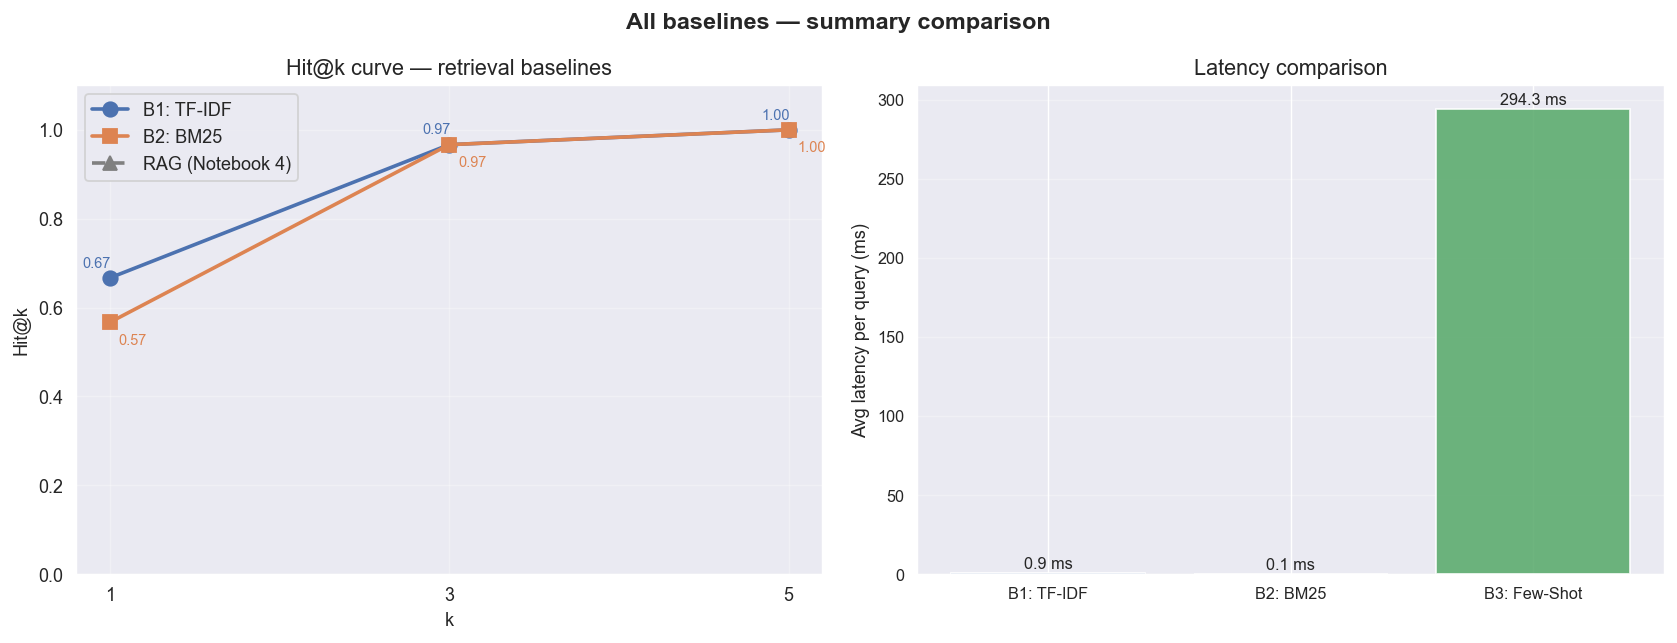

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("All baselines — summary comparison", fontsize=13, fontweight="bold")

k_vals = [1, 3, 5]
hit_tfidf = [summary_tfidf[f"Hit@{k}"] for k in k_vals]
hit_bm25 = [summary_bm25[f"Hit@{k}"] for k in k_vals]

axes[0].plot(k_vals, hit_tfidf, "o-", color=PALETTE[0], linewidth=2,
             markersize=8, label="B1: TF-IDF")
axes[0].plot(k_vals, hit_bm25, "s-", color=PALETTE[1], linewidth=2,
             markersize=8, label="B2: BM25")
axes[0].plot(k_vals, [None, None, None], "^--", color="gray",
             linewidth=2, markersize=8, label="RAG (Notebook 4)")

for k, t, b in zip(k_vals, hit_tfidf, hit_bm25):
    axes[0].annotate(f"{t:.2f}", (k, t), textcoords="offset points",
                     xytext=(-15, 6), fontsize=8, color=PALETTE[0])
    axes[0].annotate(f"{b:.2f}", (k, b), textcoords="offset points",
                     xytext=(5, -12), fontsize=8, color=PALETTE[1])

axes[0].set_xlabel("k")
axes[0].set_ylabel("Hit@k")
axes[0].set_title("Hit@k curve — retrieval baselines")
axes[0].set_ylim(0, 1.1)
axes[0].set_xticks(k_vals)
axes[0].legend()
axes[0].grid(alpha=0.3)

model_names = ["B1: TF-IDF", "B2: BM25", "B3: Few-Shot"]
latencies = [
    summary_tfidf["avg_latency_ms"],
    summary_bm25["avg_latency_ms"],
    round(df_fewshot["latency_ms"].mean(), 2)
]
bar_colors = PALETTE[:3]
bars = axes[1].bar(model_names, latencies, color=bar_colors, alpha=0.85)
for bar, val in zip(bars, latencies):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(latencies) * 0.01,
                 f"{val:.1f} ms", ha="center", fontsize=9)
axes[1].set_ylabel("Avg latency per query (ms)")
axes[1].set_title("Latency comparison")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "20_baseline_comparison.png", bbox_inches="tight")
plt.show()

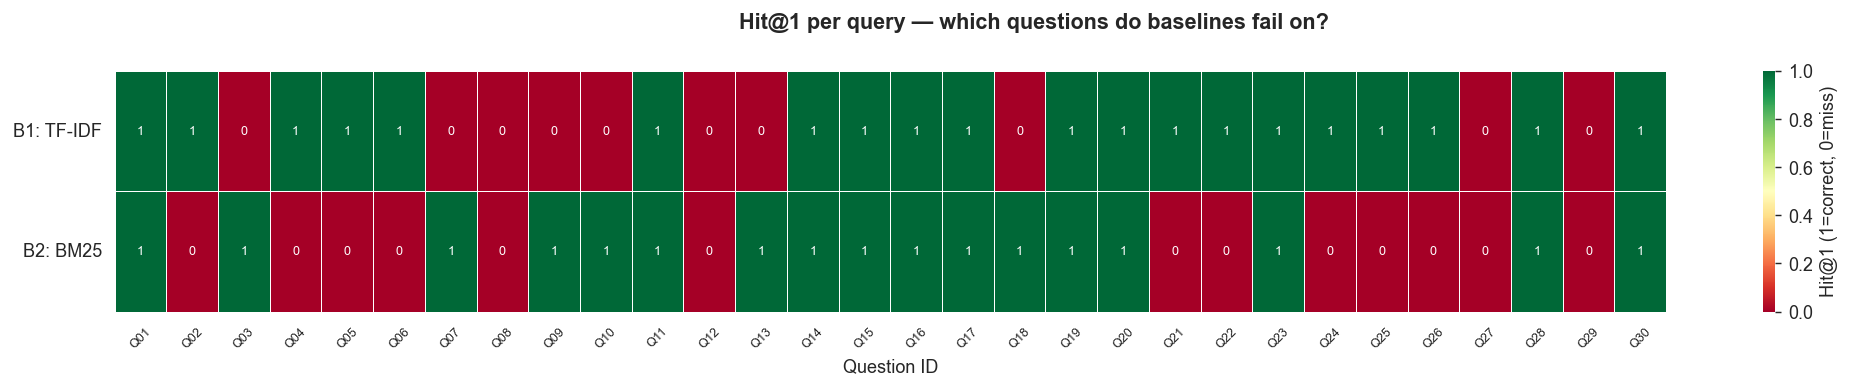

Questions where BOTH baselines fail (Hit@1=0): ['Q08', 'Q12', 'Q27', 'Q29']


In [39]:
hit1_tfidf = df_tfidf.set_index("q_id")["Hit@1"]
hit1_bm25 = df_bm25.set_index("q_id")["Hit@1"]

hit_matrix = pd.DataFrame({
    "B1: TF-IDF": hit1_tfidf,
    "B2: BM25": hit1_bm25,
}).T

fig, ax = plt.subplots(figsize=(16, 3))
fig.suptitle("Hit@1 per query — which questions do baselines fail on?",
             fontsize=12, fontweight="bold")

sns.heatmap(
    hit_matrix.astype(float),
    ax=ax,
    cmap="RdYlGn",
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Hit@1 (1=correct, 0=miss)"},
    annot=True, fmt=".0f",
    annot_kws={"size": 7}
)
ax.set_xlabel("Question ID")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "21_hit1_heatmap.png", bbox_inches="tight")
plt.show()

both_fail = [qid for qid in hit_matrix.columns
             if hit_matrix[qid].sum() == 0]
print(f"Questions where BOTH baselines fail (Hit@1=0): {both_fail}")

## 9. Save All Results

In [40]:
baseline_results = {
    "tfidf": {
        "summary": summary_tfidf,
        "per_question": df_tfidf.drop(columns=["ranked"]).to_dict(orient="records"),
    },
    "bm25": {
        "summary": summary_bm25,
        "per_question": df_bm25.drop(columns=["ranked"]).to_dict(orient="records"),
    },
    "few_shot": {
        "summary": {
            "model": "Few-Shot (llama3-8b, no retrieval)",
            "avg_rouge1_f1": round(df_fewshot["rouge1_f1"].mean(), 4),
            "hallucination_rate": round(df_fewshot["hallucinated"].mean(), 4),
            "avg_latency_ms": round(df_fewshot["latency_ms"].mean(), 2),
        },
        "per_question": few_shot_results,
    }
}

with open(OUTPUT_DIR / "baseline_results.json", "w", encoding="utf-8") as f:
    json.dump(baseline_results, f, indent=2, ensure_ascii=False)

print("Saved: outputs/baseline_results.json")
print()
print(
    f"B1 TF-IDF  : Hit@1={summary_tfidf['Hit@1']:.2f}  MRR={summary_tfidf['MRR']:.2f}  Latency={summary_tfidf['avg_latency_ms']:.1f}ms")
print(
    f"B2 BM25    : Hit@1={summary_bm25['Hit@1']:.2f}  MRR={summary_bm25['MRR']:.2f}  Latency={summary_bm25['avg_latency_ms']:.1f}ms")
print(
    f"B3 FewShot : ROUGE-1={df_fewshot['rouge1_f1'].mean():.2f}  Halluc={df_fewshot['hallucinated'].mean() * 100:.0f}%  Latency={df_fewshot['latency_ms'].mean():.0f}ms")

Saved: outputs/baseline_results.json

B1 TF-IDF  : Hit@1=0.67  MRR=0.81  Latency=0.9ms
B2 BM25    : Hit@1=0.57  MRR=0.75  Latency=0.1ms
B3 FewShot : ROUGE-1=0.00  Halluc=0%  Latency=294ms
